## Stage 1: Importing Libraries

In [2]:
# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Stage 2: Loading the Data

In [4]:
# Loading data
df = pd.read_csv(r"C:\Users\ASUS\Downloads\spam.csv",encoding = 'latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
df.columns
# v1 → label (ham/spam)
# v2 → message (actual text)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

## Stage 3: Cleaning the Data

In [8]:
# keep only two useful columns, drop the 3 empty junk columns
df = df[['v1', 'v2']]

# Rename columns to eaningful names
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Check structure - rows, columns, data types, null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
# Check how many ham vs spam messages exists
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

## Stage 4: Label Encoding

In [12]:
# convert text to numbers: ham = 0, spam = 1
df['label'] = df['label'].map({'ham':0, 'spam':1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# confirm labels are now numeric, not text
df['label'].dtype

dtype('int64')

## Stage 5: Text Preprocessing

In [15]:
# importing regex library for pattern based text cleaening
import re

# import nltk - Natuarl Language Toolkit, used for text processing
import nltk
from nltk.corpus import stopwords

# Download the stopwords list from nltk(only needed once)
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
def clean_text(text):
    text = text.lower() #lowercase
    text = re.sub(r'[^a-z0-9]',' ', text) #remove everything except letters and numbers

    words = text.split() #Split the string into a list of individual words
    words = [i for i in words if i not in stopwords.words('english')]#Keeps only meaningful words

    return  " ".join(words)#Join remaining words into one single string

In [17]:
# Apply clean_text to every row in the message column
# .apply() runs the function once for each message automatically
df['message'] = df['message'].apply(clean_text)

df.head()

,label,message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c already say
4,0,nah think goes usf lives around though


 ## Stage 6: TF-IDF Vectorization

In [19]:
# import TF-IDF vectorizer from scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the vectorizer
# max_features=3000 means we only keep the 3000 most important words
# This keeps the model efficient without lloosing much signal
tfidf = TfidfVectorizer(max_features=3000)

'''Fit the vectorizer on all messages and transform them into numbers
fit: learns which 3000 words to track and calculates IDF scores
transform: converts each message into a row of 3000 numbers
toarray(): converts the result into a regular numpy array'''
x = tfidf.fit_transform(df['message']).toarray()

#Extract the labels column as our target variable
y = df['label']

In [20]:
print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (5572, 3000)
Y shape: (5572,)


## Stage 7: Train/Test Split

In [22]:
# import the train-test-split fuction from sklearn
from sklearn.model_selection import train_test_split

'''Split data into training and testing sets
 x = input features (TF-IDF matrix)
 y = labels (0=ham, 1=spam)
 test_size=0.2 means 20% goes to testing, 80% to training
 random_state=42 ensures you get the same split every time you run this'''

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [23]:
# Confirm the split sizes are what we expect
print("Training size:", x_train.shape)
print("Testing size:", x_test.shape)

# You should see roughly (4457, 3000) for training and (1115, 3000) for testing.

# **A visual way to think about this:**

# All data (5572 messages)
# ├── Training set (4457) → model learns from this
# └── Testing set  (1115) → model gets evaluated on this
#                           model has NEVER seen these before


Training size: (4457, 3000)
Testing size: (1115, 3000)


## Stage 8: Training the Model

In [25]:
# Import Multinomial Naive Bayes from scikit-learn
from sklearn.naive_bayes import MultinomialNB

# Create the model
model = MultinomialNB()

# Train the model on the training data
# x_train: TF-IDF features the model learns from
# y_train: correct labels (0 or 1) for each training message
model.fit(x_train, y_train)

MultinomialNB()

In [26]:
# Use the trained model to predict labels for the test set
# The model has never seen these 1115 messages before
y_pred = model.predict(x_test)

In [27]:
# Preview first 10 predictions vs actual labels
print("Predicted:", y_pred)
print("Actual:   ", y_test.values)

Predicted: [0 0 1 ... 0 0 1]
Actual:    [0 0 1 ... 0 0 1]


## Stage 9: Evaluation

In [29]:
# import accuracy_score from sklearn-metrics
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy,2))

Accuracy: 0.98


In [30]:
# Import classification report
from sklearn.metrics import classification_report

# Prints precision, recall and f1-score for each class
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [31]:
# Import confusion matrix
from  sklearn.metrics import confusion_matrix

# TO generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

'''
 You'll see a 2×2 grid like this:

[[964   1]
 [ 23 127]]

Here is exactly what each number means:

                  Predicted Ham    Predicted Spam
Actual Ham            964               1
Actual Spam            23             127       '''

[[964   1]
 [ 23 127]]


"\n You'll see a 2×2 grid like this:\n\n[[964   1]\n [ 23 127]]\n\nHere is exactly what each number means:\n\n                  Predicted Ham    Predicted Spam\nActual Ham            964               1\nActual Spam            23             127       "

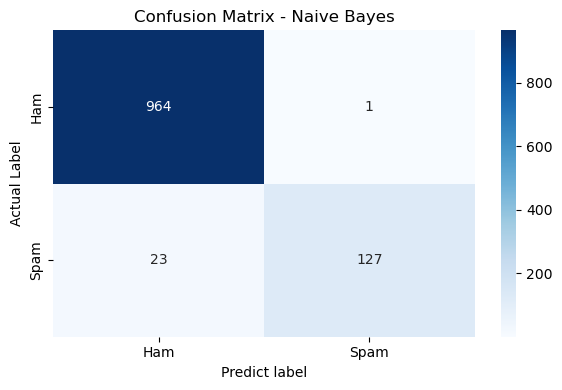

In [32]:
# Plot confusion matrix as a heatmap for visual evaluation
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
    )

plt.xlabel("Predict label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Naive Bayes")
plt.tight_layout()
plt.show()

## Stage 10: The Prediction Function

In [34]:
def predict_spam(text):
    text = clean_text(text)
    vector = tfidf.transform([text]).toarray()
    results = model.predict(vector)[0]

    return "SPAM" if results == 1 else "NOT SPAM"

In [35]:
# Test with an obvious spam message
print(predict_spam("Congratulations! You have won 5000 rupees.!"))

# Test with a normal message
print(predict_spam("Hey are you coming for lunch today?"))

# Test with a tricky spam message
print(predict_spam("Free entry win FA Cup tickets call now"))

# Test with your own message
print(predict_spam("Can you send me the notes from yesterday's class?"))

SPAM
NOT SPAM
SPAM
NOT SPAM


## other models, for comapirng which one is more greatful

In [77]:
# import all three models and accuracy metric
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# store all models in a dictionary for clean iteration
models = {
    'XGBoost':XGBClassifier(
    n_estimators=100,     # number of trees
    learning_rate=0.1,    # contribution of each tree
    max_depth=4,          # depth of each tree
    subsample=0.8,        # fraction of data per tree
    random_state=42,
    eval_metric='logloss',# suppress warnings
    verbosity=0           # suppress output
),
    'Random Forest': RandomForestClassifier( n_estimators=100,max_depth   = None,random_state= 42),
    'Naive Bayes' : MultinomialNB(),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'SVM' : LinearSVC()
}
#max_iter is how many times the algorithm iterates to find the best solution. 
#Default is 100 which sometimes isn't enough for text data, causing a warning. 
#1000 ensures it fully converges.

In [79]:
## train each model and collect evaluation metrics
print(f"{'model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 100)

results = {} # store results for plotting later

for name, clf in models.items():
    # train the model on training data
    clf.fit(x_train, y_train)

    # predict on test data
    pred = clf.predict(x_test)

    # calculate all four metrics
    acc = accuracy_score(y_test, pred)
    pres = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    # store results for visualization
    results[name] = [acc, pres, rec, f1]

    # print formatted results now
    print(f"{name:<25} {acc:>10.4f} {pres:>10.4f} {rec:>10.4f} {f1:>10.4f}")

model                       Accuracy  Precision     Recall         F1
----------------------------------------------------------------------------------------------------
XGBoost                       0.9740     0.9919     0.8133     0.8938
Random Forest                 0.9767     0.9921     0.8333     0.9058
Naive Bayes                   0.9785     0.9922     0.8467     0.9137
Logistic Regression           0.9587     0.9643     0.7200     0.8244
SVM                           0.9776     0.9699     0.8600     0.9117


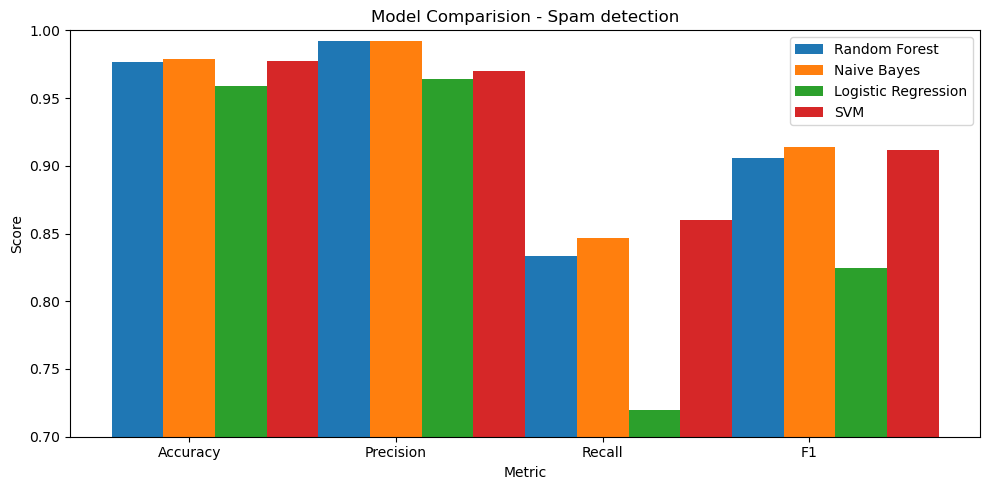

In [39]:
# plot model comparison as a grouped bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

#Plot one group of bars per model
for i, (name, scores) in enumerate(results.items()):
    ax.bar(x_pos + i * width, scores, width, label=name)

#Formatting
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparision - Spam detection")
ax.set_xticks(x_pos + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.0)   # zoom in on 0.8-1.0 range to see differences clearly
ax.legend()
plt.tight_layout()
plt.show()

# Clean Summary Output

In [41]:
# ============================================================
# PROJECT SUMMARY - SMS Spam Detector
# ============================================================

print('=' * 50)
print('        SMS SPAM DETECTOR - PROJECT SUMMARY ')
print('=' * 50)

# Dataset Information
print("\n📊 DATASET")
print(f"   Total messages     : {len(df)}")
print(f"   ham messages       : {(df['label'] == 0).sum()}")
print(f"   Spam messages      : {(df['label'] == 1).sum()}")
print(f"   Class Imbalance    : {round((df['label'] == 0).sum() / (df['label'] == 1).sum(),2)}x more ham than spam ")

# Train-Test-Split Information
print("\n🔀 TRAIN / TEST SPLIT")
print(f"   Training Samples   : {x_train.shape[0]}")
print(f"   Testing Samples    : {x_test.shape[0]}")
print(f"   Features (TF-IDF)  : {x_train.shape[1]}")

# Model comparison results
print("\n🤖 MODEL COMPARISON")
print(f"   {'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("   " + "-" * 50)
for name, scores in results.items():
    print(f"   {name:<25} {scores[0]:>10.4f} {scores[1]:>10.4f} {scores[2]:>10.4f} {scores[3]:>10.4f}")

# Winner
best_model = max(results, key=lambda x: results[x][3])
print(f"\n🏆 BEST MODEL : {best_model}")
print(f"   Reason     : Highest F1 score with near-zero false positives")
print(f"   Precision  : {results[best_model][1]:.4f} (when it says spam, it is almost always right)")
print(f"   Recall     : {results[best_model][2]:.4f} (catches this percentage of all real spam)")

# Final test
print("\n✅ LIVE PREDICTIONS")
test_messages = [
    "Congratulations! You won 5000 rupees. Click now!",
    "Hey are you coming for lunch today?",
    "Free entry win FA Cup tickets call now",
    "Can you send me the notes from class?"
]
for msg in test_messages:
    prediction = predict_spam(msg)
    label  = "🚨 SPAM   " if prediction == "SPAM" else "✅ NOT SPAM"
    print(f"   {label} → {msg[:50]}...")

print("\n" + "=" * 50)
print("   Model built with Naive Bayes + TF-IDF vectorization")
print("   Dataset : SMS Spam Collection (UCI Repository)")
print("=" * 50)

        SMS SPAM DETECTOR - PROJECT SUMMARY 

📊 DATASET
   Total messages     : 5572
   ham messages       : 4825
   Spam messages      : 747
   Class Imbalance    : 6.46x more ham than spam 

🔀 TRAIN / TEST SPLIT
   Training Samples   : 4457
   Testing Samples    : 1115
   Features (TF-IDF)  : 3000

🤖 MODEL COMPARISON
   Model                       Accuracy  Precision     Recall         F1
   --------------------------------------------------
   Random Forest                 0.9767     0.9921     0.8333     0.9058
   Naive Bayes                   0.9785     0.9922     0.8467     0.9137
   Logistic Regression           0.9587     0.9643     0.7200     0.8244
   SVM                           0.9776     0.9699     0.8600     0.9117

🏆 BEST MODEL : Naive Bayes
   Reason     : Highest F1 score with near-zero false positives
   Precision  : 0.9922 (when it says spam, it is almost always right)
   Recall     : 0.8467 (catches this percentage of all real spam)

✅ LIVE PREDICTIONS
   🚨 SPAM   

In [42]:
# Import pickle - Pythons built in library for saving objets to file
import pickle

# save the tarined model to file
# 'wb' means write in binary mode - required for pickle
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the TF-IDF vectorizer toa file
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
